# Notebook 1 — Representación de señales y transformada de Fourier

## Objetivo

En este notebook se estudia de manera experimental la representación de señales en el dominio temporal y en el dominio frecuencial. El objetivo es ilustrar tres ideas fundamentales para el desarrollo posterior del TFG:

1. una señal puede modelarse como combinación de componentes sinusoidales simples;
2. la transformada discreta de Fourier permite identificar las frecuencias presentes en la señal;
3. muchas señales presentan una representación más compacta en el dominio frecuencial que en el dominio temporal.

Este análisis constituye la base conceptual para introducir posteriormente el teorema de Shannon--Nyquist, la noción de sparsidad y el marco de *Compressed Sensing*.

In [20]:
"""
He empezado por el bloque más básico y fundacional del TFG: la representación de señales en la base de Fourier. 
En este notebook genero señales sintéticas simples, estudio su transformada discreta de Fourier, verifico la reconstrucción por 
transformada inversa y analizo qué ocurre al conservar solo un número reducido de coeficientes. La idea es construir experimentalmente 
la intuición de compacidad que después justificaría la sparsidad y el paso a compressed sensing.
"""

"""
Básicamente, para enterarme yo de que estoy haciendo, la idea es que una señal cuna señal puede parecer compleja en el dominio temporal,
pero simple y 
compacta en una base adecuada, como la de Fourier.
"""

'\nBásicamente, para enterarme yo de que estoy haciendo, la idea es que una señal cuna señal puede parecer compleja en el dominio temporal,\npero simple y \ncompacta en una base adecuada, como la de Fourier.\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración gráfica
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 1. Definición de parámetros de muestreo

Se fija una frecuencia de muestreo y una duración total de observación. A partir de estos parámetros se construye el eje temporal discreto sobre el que se evaluarán las señales.

In [2]:
# Parámetros globales
fs = 500              # frecuencia de muestreo en Hz
T = 1.0               # duración total en segundos
N = int(fs * T)       # número total de muestras

t = np.linspace(0, T, N, endpoint=False)

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Duración total: {T} s")
print(f"Número de muestras: {N}")

Frecuencia de muestreo: 500 Hz
Duración total: 1.0 s
Número de muestras: 500


## 2. Funciones auxiliares

Se definen varias funciones para:

- calcular la transformada discreta de Fourier,
- reconstruir señales,
- conservar únicamente los coeficientes más significativos,
- y medir el error de reconstrucción.

In [4]:
def compute_fft(signal, fs):
    """
    Calcula la FFT de una señal y devuelve frecuencias positivas y magnitudes.
    """
    N = len(signal)
    fft_coeffs = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)

    mask = freqs >= 0
    return freqs[mask], fft_coeffs[mask], fft_coeffs


def reconstruct_from_fft(full_fft):
    """
    Reconstruye la señal usando la transformada inversa de Fourier.
    """
    return np.fft.ifft(full_fft).real


def keep_top_k_coeffs(full_fft, k):
    """
    Conserva los k coeficientes de mayor magnitud y anula el resto.
    """
    fft_copy = np.copy(full_fft)
    magnitudes = np.abs(fft_copy)

    # Índices de los k coeficientes de mayor magnitud
    top_k_idx = np.argsort(magnitudes)[-k:]

    filtered_fft = np.zeros_like(fft_copy, dtype=complex)
    filtered_fft[top_k_idx] = fft_copy[top_k_idx]
    return filtered_fft


def mse(x, x_hat):
    return np.mean((x - x_hat) ** 2)


def relative_error(x, x_hat):
    return np.linalg.norm(x - x_hat) / np.linalg.norm(x)

## 3. Experimento 1: señal sinusoidal simple

Se comienza con una señal elemental compuesta por una única senoide. Este experimento permite comprobar que una señal simple en el dominio temporal genera un espectro con una frecuencia dominante claramente identificable.

In [22]:
# Señal 1: senoide simple
f1 = 5  # Hz
signal_1 = np.sin(2 * np.pi * f1 * t)

freqs_1, fft_pos_1, fft_full_1 = compute_fft(signal_1, fs)
magnitude_1 = np.abs(fft_pos_1) / N


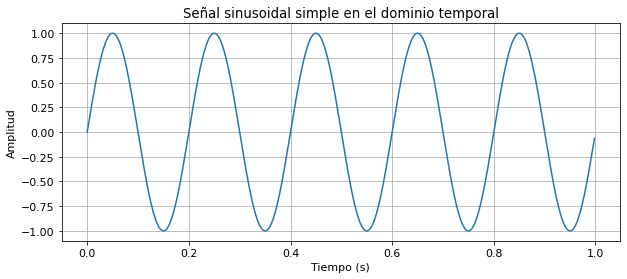

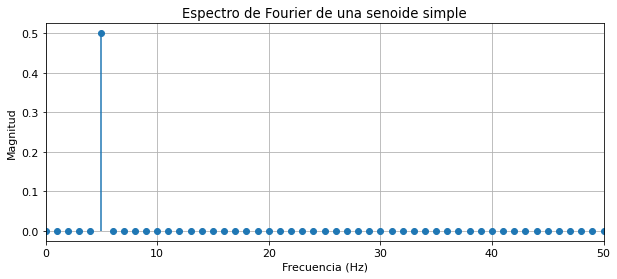

In [7]:
# Señal en el dominio temporal
plt.figure()
plt.plot(t, signal_1)
plt.title("Señal sinusoidal simple en el dominio temporal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

# Espectro de Fourier
plt.figure()
plt.stem(freqs_1, magnitude_1, basefmt=" ")
plt.xlim(0, 50)
plt.title("Espectro de Fourier de una senoide simple")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

### Comentario

Tal como cabía esperar, el espectro presenta un pico dominante en la frecuencia correspondiente a la senoide generada. Esto confirma que la transformada de Fourier identifica correctamente la estructura oscilatoria básica de la señal.

## 4. Experimento 2: suma de varias senoides

A continuación se considera una señal más compleja, formada como suma de varias componentes sinusoidales con distintas frecuencias y amplitudes. El objetivo es comprobar que la transformada de Fourier sigue permitiendo separar y detectar dichas componentes de manera clara.

In [9]:
# Señal 2: suma de senoides
f1, f2, f3 = 5, 15, 40
a1, a2, a3 = 1.0, 0.7, 0.3

signal_2 = (
    a1 * np.sin(2 * np.pi * f1 * t) +
    a2 * np.sin(2 * np.pi * f2 * t) +
    a3 * np.sin(2 * np.pi * f3 * t)
)

freqs_2, fft_pos_2, fft_full_2 = compute_fft(signal_2, fs)
magnitude_2 = np.abs(fft_pos_2) / N

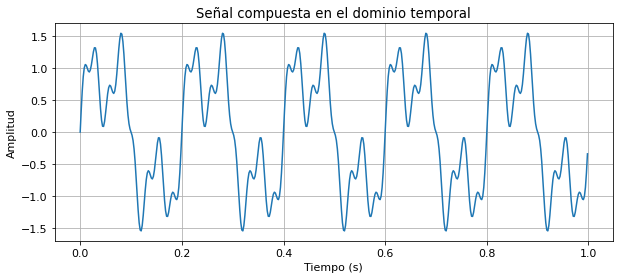

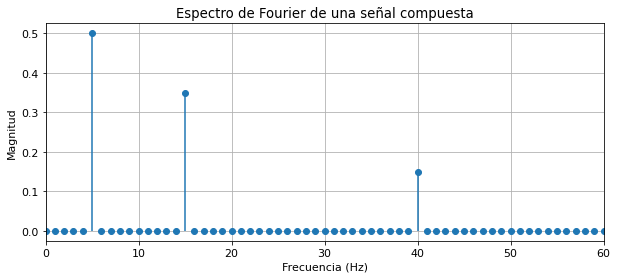

In [10]:
# Señal en tiempo
plt.figure()
plt.plot(t, signal_2)
plt.title("Señal compuesta en el dominio temporal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

# Espectro
plt.figure()
plt.stem(freqs_2, magnitude_2, basefmt=" ")
plt.xlim(0, 60)
plt.title("Espectro de Fourier de una señal compuesta")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

### Comentario

Aunque la señal en el dominio temporal presenta una forma aparentemente más compleja, en el dominio frecuencial se observan con claridad picos localizados en las frecuencias introducidas. Esto pone de manifiesto que la señal posee una representación estructurada y compacta en la base de Fourier.

## 5. Reconstrucción exacta mediante la transformada inversa

Una vez obtenidos los coeficientes de Fourier, se reconstruye la señal aplicando la transformada inversa. Este experimento permite verificar que la transformada no destruye información, sino que simplemente cambia la representación de la señal.

In [12]:
signal_2_reconstructed = reconstruct_from_fft(fft_full_2)

mse_exact = mse(signal_2, signal_2_reconstructed)
rel_exact = relative_error(signal_2, signal_2_reconstructed)

print(f"MSE reconstrucción exacta: {mse_exact:.12f}")
print(f"Error relativo reconstrucción exacta: {rel_exact:.12e}")

MSE reconstrucción exacta: 0.000000000000
Error relativo reconstrucción exacta: 2.425258537862e-16


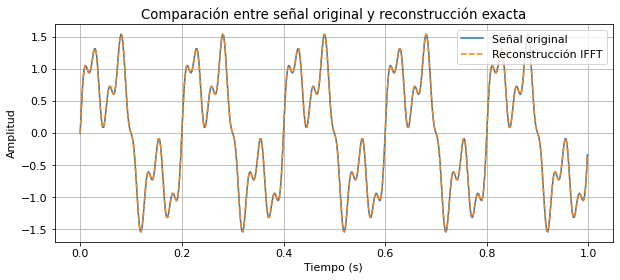

In [13]:
plt.figure()
plt.plot(t, signal_2, label="Señal original")
plt.plot(t, signal_2_reconstructed, "--", label="Reconstrucción IFFT")
plt.title("Comparación entre señal original y reconstrucción exacta")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

### Comentario

La señal reconstruida coincide con la señal original salvo pequeñas diferencias numéricas debidas al cálculo computacional. Esto confirma la equivalencia entre la representación temporal y la representación frecuencial.

## 6. Aproximación con un número reducido de coeficientes

En este apartado se estudia una cuestión especialmente relevante para el TFG: qué ocurre si, en lugar de conservar todos los coeficientes de Fourier, se retienen únicamente los más significativos.

Este experimento permite introducir de forma visual la idea de compresibilidad: una señal puede aproximarse razonablemente bien usando solo una pequeña fracción de sus coeficientes en una base adecuada.

In [23]:
k_values = [2, 4, 6, 10, 20, 50]
results = []

for k in k_values:
    fft_k = keep_top_k_coeffs(fft_full_2, k)
    signal_k = reconstruct_from_fft(fft_k)

    results.append({
        "k": k,
        "mse": mse(signal_2, signal_k),
        "relative_error": relative_error(signal_2, signal_k),
        "reconstruction": signal_k
    })

results

#esto igual lo puedo cambiar para escribirlo en vez de como lista de diccionarios como un pandas dataframe pero bueno lo dejo así de moemnto

[{'k': 2,
  'mse': 0.29,
  'relative_error': 0.6058783768999656,
  'reconstruction': array([-1.91359246e-16,  6.27905195e-02,  1.25333234e-01,  1.87381315e-01,
          2.48689887e-01,  3.09016994e-01,  3.68124553e-01,  4.25779292e-01,
          4.81753674e-01,  5.35826795e-01,  5.87785252e-01,  6.37423990e-01,
          6.84547106e-01,  7.28968627e-01,  7.70513243e-01,  8.09016994e-01,
          8.44327926e-01,  8.76306680e-01,  9.04827052e-01,  9.29776486e-01,
          9.51056516e-01,  9.68583161e-01,  9.82287251e-01,  9.92114701e-01,
          9.98026728e-01,  1.00000000e+00,  9.98026728e-01,  9.92114701e-01,
          9.82287251e-01,  9.68583161e-01,  9.51056516e-01,  9.29776486e-01,
          9.04827052e-01,  8.76306680e-01,  8.44327926e-01,  8.09016994e-01,
          7.70513243e-01,  7.28968627e-01,  6.84547106e-01,  6.37423990e-01,
          5.87785252e-01,  5.35826795e-01,  4.81753674e-01,  4.25779292e-01,
          3.68124553e-01,  3.09016994e-01,  2.48689887e-01,  1.8738131

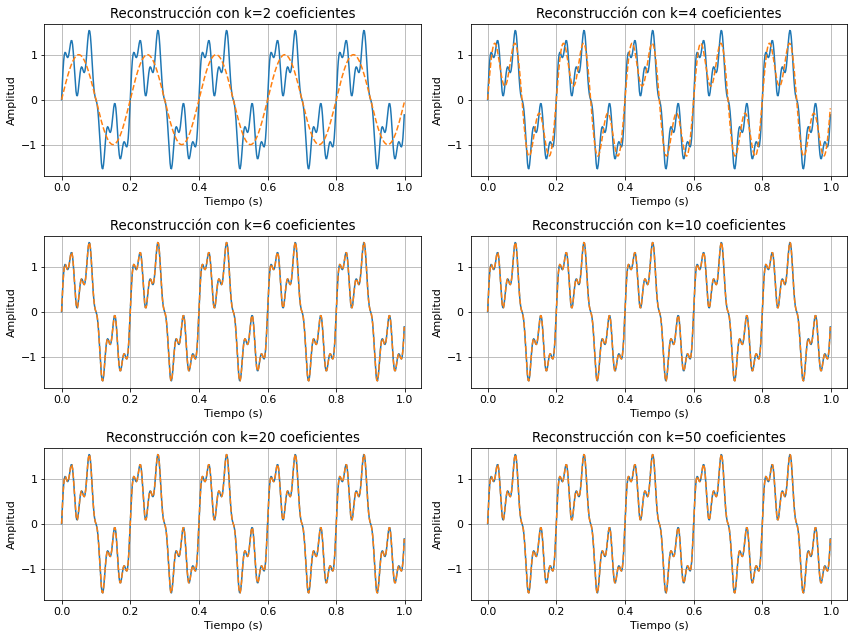

In [15]:
# Mostrar algunas reconstrucciones
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, result in zip(axes, results):
    ax.plot(t, signal_2, label="Original")
    ax.plot(t, result["reconstruction"], "--", label=f"k={result['k']}")
    ax.set_title(f"Reconstrucción con k={result['k']} coeficientes")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

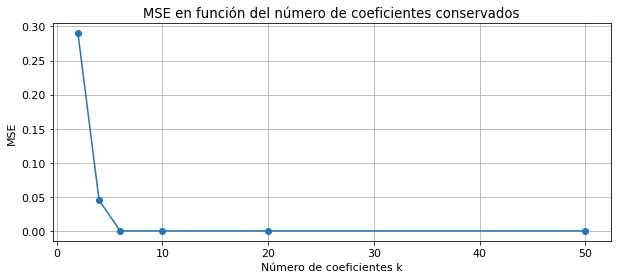

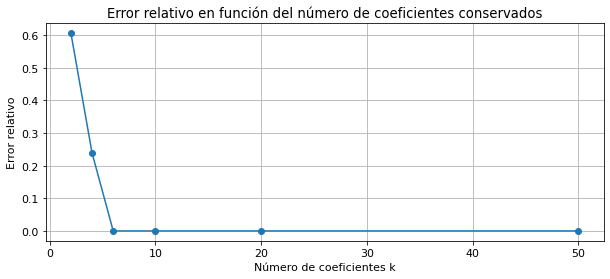

In [16]:
# Error frente a k
k_list = [r["k"] for r in results]
mse_list = [r["mse"] for r in results]
rel_list = [r["relative_error"] for r in results]

plt.figure()
plt.plot(k_list, mse_list, marker="o")
plt.title("MSE en función del número de coeficientes conservados")
plt.xlabel("Número de coeficientes k")
plt.ylabel("MSE")
plt.show()

plt.figure()
plt.plot(k_list, rel_list, marker="o")
plt.title("Error relativo en función del número de coeficientes conservados")
plt.xlabel("Número de coeficientes k")
plt.ylabel("Error relativo")
plt.show()

In [17]:
# Tabla resumen
for r in results:
    print(
        f"k={r['k']:>2} | "
        f"MSE={r['mse']:.8f} | "
        f"Error relativo={r['relative_error']:.8f}"
    )

k= 2 | MSE=0.29000000 | Error relativo=0.60587838
k= 4 | MSE=0.04500000 | Error relativo=0.23866719
k= 6 | MSE=0.00000000 | Error relativo=0.00000000
k=10 | MSE=0.00000000 | Error relativo=0.00000000
k=20 | MSE=0.00000000 | Error relativo=0.00000000
k=50 | MSE=0.00000000 | Error relativo=0.00000000


### Interpretación

Se observa que, al aumentar el número de coeficientes retenidos, el error de reconstrucción disminuye de forma progresiva. En particular, incluso utilizando solo una pequeña parte de los coeficientes totales, la señal puede aproximarse con bastante fidelidad.

Este resultado es importante porque anticipa una de las ideas centrales del trabajo: aunque una señal tenga muchas muestras en el dominio temporal, su información esencial puede concentrarse en pocas componentes relevantes en una base adecuada.

## 7. Conclusiones del notebook

Los experimentos realizados permiten extraer varias conclusiones:

1. la transformada de Fourier identifica correctamente las frecuencias presentes en una señal;
2. la transformada inversa permite reconstruir la señal original sin pérdida de información significativa;
3. una señal compuesta puede presentar una representación mucho más compacta en el dominio frecuencial;
4. conservar únicamente los coeficientes más significativos sigue permitiendo una reconstrucción razonablemente precisa.

Estas observaciones justifican el interés de estudiar la señal en una base adecuada y preparan el terreno para los siguientes bloques del TFG, dedicados al muestreo, la sparsidad y la reconstrucción a partir de medidas incompletas.

In [24]:
"""
¿Para qué me sirve este nb?
Porque esa es la puerta de entrada a todo lo demás:

Shannon depende del contenido en frecuencia,
la sparsidad depende de la representación,
compressed sensing depende de que exista una base donde la señal sea simple.
"""

'\n¿Para qué me sirve este nb?\nPorque esa es la puerta de entrada a todo lo demás:\n\nShannon depende del contenido en frecuencia,\nla sparsidad depende de la representación,\ncompressed sensing depende de que exista una base donde la señal sea simple.\n'